# IS 4487 Assignment 18: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [9]:
# Replace this list with your selected tickers
tickers = ['SYY', 'USFD', 'MCK', 'GPC']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [10]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [11]:
# Download adjusted close prices
df = yf.download(tickers, start="2020-11-20", end="2025-11-20")['High']

/tmp/ipython-input-1629662952.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-11-20", end="2025-11-20")['High']
[*********************100%***********************]  4 of 4 completed


In [12]:
df.head()

Ticker,GPC,MCK,SYY,USFD
Date,,,,
2020-11-20,85.475337,167.351559,62.832008,30.530001
2020-11-23,85.640910,169.057549,62.981499,30.760000
2020-11-24,88.490966,175.648858,64.916158,32.889999
2020-11-25,87.776260,175.833049,63.808119,32.520000
2020-11-27,86.460177,176.191714,63.570684,32.459999


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [13]:
df.isnull().sum()

,0
Ticker,
GPC,0
MCK,0
SYY,0
USFD,0


There are no missing values in this dataset.

## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [14]:
daily_returns_df = df.pct_change()


In [15]:
daily_returns_df = daily_returns_df.dropna()


In [16]:
daily_returns_df.head()

Ticker,GPC,MCK,SYY,USFD
Date,,,,
2020-11-23,0.001937,0.010194,0.002379,0.007534
2020-11-24,0.033279,0.038989,0.030718,0.069246
2020-11-25,-0.008077,0.001049,-0.017069,-0.011250
2020-11-27,-0.014994,0.002040,-0.003721,-0.001845
2020-11-30,-0.007157,0.006474,-0.013418,-0.011091


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




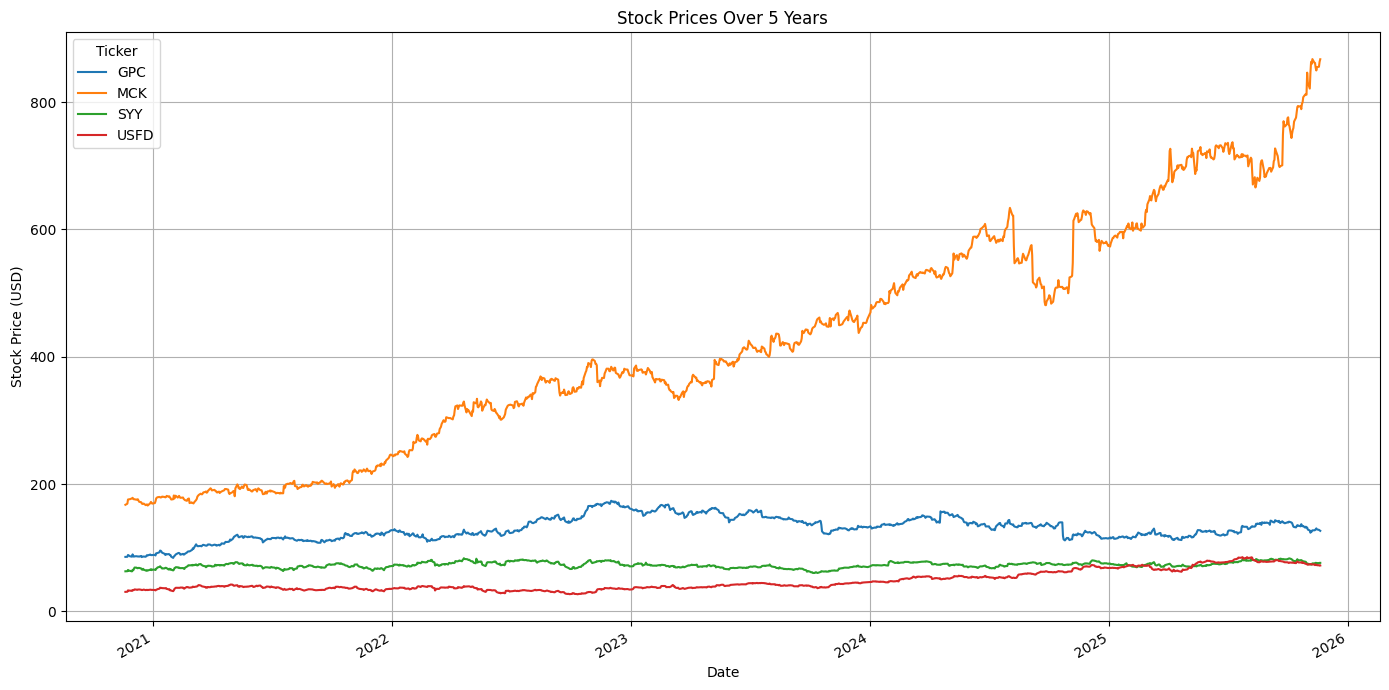

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
df.plot(ax=plt.gca())
plt.title('Stock Prices Over 5 Years')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.grid(True)
plt.legend(title='Ticker')
plt.tight_layout()
plt.show()

In [18]:
daily_returns_std = daily_returns_df.std()
print("Standard Deviation of Daily Returns (Volatility):")
print(daily_returns_std)

Standard Deviation of Daily Returns (Volatility):
Ticker
GPC     0.013997
MCK     0.013417
SYY     0.013205
USFD    0.017106
dtype: float64


In [19]:
correlation_matrix = daily_returns_df.corr()
print("Correlation Matrix of Daily Returns:")
print(correlation_matrix)

Correlation Matrix of Daily Returns:
Ticker       GPC       MCK       SYY      USFD
Ticker                                        
GPC     1.000000  0.190369  0.400835  0.356524
MCK     0.190369  1.000000  0.170983  0.149529
SYY     0.400835  0.170983  1.000000  0.611131
USFD    0.356524  0.149529  0.611131  1.000000


## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



I analyzed the distribution services industry. The companies I included in my analysis were Sysco Coropration, US Foods Corporation, McKesson Corporation, and Genuine Parts Company. Sysco and US Foods are both broadline foodservice distributors, mainly serving restaurants, caterers, and other commercial foodservice businesses. McKesson distributes pharmaceutical products and medical supplies. Genuine Parts Company distributes auto and industrial parts.

While conducting my analysis, I observed very stable stock prices across a five-year period, with the exception of McKesson Corporation. MCK stock has seen an upward climb over the past five years, with some slight dips. MCK stock has massively gained over the past five years. The other three stocks have remained extremely stable over this time horizon.

In terms of volatility, USFD is slightly more volatile than the other three stocks. USFD and SYY, US Foods and Sysco, are 61.1% correlated. This is likely because they are close competitors, and are both major players in the foodservice distribution industry.

Currently, I would recommend investing in the distribution services industry. Products will ALWAYS needs to be distributed across the world, and these companies help facilitate that every day. It is a reliable, steady industry to invest in. Currently, these stocks are not too high and not too low to recommend investing in right now. This can be seen in my line chart. McKesson is quite high, so I might wait and see if this particular stock pulls back before investing in it.

For future analysis, I would recommend looking at quartlerly earnings reports released by distribution services companies such as the four I analyzed here. Earnings reports can provide timely insights on the state of the industry, as well as the health of the general economy. I would recommend updating your analysis every month, as stock prices can rapidly change. Earnings reports come out every three months for publicly traded companies, and this is important to keep on top of. Risk modeling for specific stocks can help you make investment decisions as well. This can be an important step.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [20]:
!jupyter nbconvert --to html "assignment_14_api.ipynb"

[NbConvertApp] Converting notebook assignment_14_api.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 450695 bytes to assignment_14_api.html
